## 2.4 微积分

### 2.4.1 导数和微分

In [13]:
%matplotlib inline
import numpy as np
from matplotlib_inline import backend_inline
from d2l import torch as d2l
d2l.plt.rcParams['font.family'] = 'Microsoft YaHei'

def f(x):
    return 3 * x ** 2 - 4 * x

In [3]:
def numerical_lim(f, x, h):
    return (f(x + h) - f(x)) / h

h = 0.1
for i in range(5):
    print(f'h={h:.5f}, numerical limit={numerical_lim(f, 1, h):.5f}')
    h *= 0.1

h=0.10000, numerical limit=2.30000
h=0.01000, numerical limit=2.03000
h=0.00100, numerical limit=2.00300
h=0.00010, numerical limit=2.00030
h=0.00001, numerical limit=2.00003


为了对导数的这种解释进行可视化，我们将使用matplotlib， 这是一个Python中常用的绘图库。 要配置matplotlib生成图形的属性，我们需要定义几个函数。 在下面，`use_svg_display`函数指定matplotlib软件包输出svg图表以获得更清晰的图像。

注意，注释#@save是一个特殊的标记，会将对应的函数、类或语句保存在d2l包中。 因此，以后无须重新定义就可以直接调用它们（例如，`d2l.use_svg_display()`）。

In [4]:
def use_svg_display():  #@save
    """使用svg格式在Jupyter中显示绘图"""
    backend_inline.set_matplotlib_formats('svg')

我们定义`set_figsize`函数来设置图表大小。 注意，这里可以直接使用`d2l.plt`，因为导入语句`from matplotlib import pyplot as plt`已标记为保存到d2l包中。

In [5]:
def set_figsize(figsize=(3.5, 2.5)):  #@save
    """设置matplotlib的图表大小"""
    use_svg_display()
    d2l.plt.rcParams['figure.figsize'] = figsize

下面的`set_axes`函数用于设置由matplotlib生成图表的轴的属性。

In [6]:
#@save
def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """设置matplotlib的轴"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

通过这三个用于图形配置的函数，定义一个`plot`函数来简洁地绘制多条曲线， 因为我们需要在整个书中可视化许多曲线。

In [7]:
#@save
def plot(X, Y=None, xlabel=None, ylabel=None, legend=None, xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
    """绘制数据点"""
    if legend is None:
        legend = []

    set_figsize(figsize)
    axes = axes if axes else d2l.plt.gca()

    # 如果X有一个轴，输出True
    def has_one_axis(X):
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
                and not hasattr(X[0], "__len__"))

    if has_one_axis(X):
        X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        if len(x):
            axes.plot(x, y, fmt)
        else:
            axes.plot(y, fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

现在我们可以绘制函数$u=f(x)$及其在$x=1$处的切线$y=2x-3$， 其中系数$2$是切线的斜率。

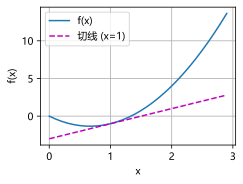

In [14]:
x = np.arange(0, 3, 0.1)
plot(x, [f(x), 2 * x - 3], 'x', 'f(x)', legend=['f(x)', '切线 (x=1)'])

### 2.4.2 偏导数
在深度学习中，函数通常依赖于许多变量，我们需要将微分的思想推广到多元函数（multivariate function）上。
设$y=f(x_1,x_2,\ldots,x_n)$是一个具有$n$个变量的函数。$y$关于第$i$个参数$x_i$的偏导数（partial derivative）为：
$$\frac{\partial y}{\partial x_i}=\lim_{h \to 0} \frac{f(x_1,\ldots,x_{i-1},x_i+h,x_{i+1},\ldots,x_n)-f(x_1,\ldots,x_i,\ldots,x_n)}{h}$$
为了计算$\frac{\partial y}{\partial x_i}$，我们可以简单地将$x_1,\ldots,x_{i-1},x_{i+1},\ldots,x_n$看作常数，并计算$y$关于$x_i$的导数。对于偏导数的表示，以下是等价的：
$$\frac{\partial y}{\partial x_i}=\frac{\partial f}{\partial x_i}=f_{x_i}=f_i=D_{i}f=D_{x_i}f$$


### 2.4.3 梯度
我们可以连结一个多元函数对其所有变量的偏导数，以得到该函数的梯度（gradient）向量。具体而言，设函数$f:\mathbb{R}^{n} \to \mathbb{R}$的输入是一个$n$维向量$\mathbf{x}=[x_1,x_2,\ldots,x_n]^\top$，并且输出是一个标量。函数$f(\mathbf{x})$相对于$\mathbf{x}$的梯度是一个包含$n$个偏导数的向量：
$$\nabla_\mathbf{x} f(\mathbf{x})=\left[\frac{\partial f(\mathbf{x})}{\partial x_1},\frac{\partial f(\mathbf{x})}{\partial x_2},\ldots,\frac{\partial f(\mathbf{x})}{\partial x_n}\right]^\top$$
其中$\nabla_\mathbf{x} f(\mathbf{x})$通常在没有歧义时被$\nabla f(\mathbf{x})$取代。

假设$\mathbf{x}$为$n$维向量，在微分多元函数时经常使用以下规则：
- 对于所有$\mathbf{A} \in \mathbb{R}^{m\times n}$，都有$\nabla_\mathbf{x}\mathbf{Ax}=\mathbf{A}^\top$
- 对于所有$\mathbf{A} \in \mathbb{R}^{n\times m}$，都有$\nabla_\mathbf{x}\mathbf{x}^\top\mathbf{A}=\mathbf{A}$
- 对于所有$\mathbf{A} \in \mathbb{R}^{n\times n}$，都有$\nabla_\mathbf{x}\mathbf{x}^\top\mathbf{Ax}=\left(\mathbf{A}+\mathbf{A}^\top\right)^\mathbf{x}$
- $\nabla_\mathbf{x}\|\mathbf{x}\|^{2}=\nabla_\mathbf{x}\mathbf{x}^\top\mathbf{x}=2\mathbf{x}$

同样，对于任何矩阵$\mathbf{X}$，都有$\nabla_\mathbf{X}\|\mathbf{X}\|_{\mathbf{F}}^{2}=2\mathbf{X}$。正如我们之后将看到的，梯度对于设计深度学习中的优化算法有很大用处。


### 2.4.4 链式法则
在深度学习中，多元函数通常是复合（composite）的，所以难以应用上述任何规则来微分这些函数，链式法则可以被用来微分复合函数。

我们先考虑单变量函数。假设函数$y=f(u)$和$u=g(x)$都是可微的，根据链式法则：
$$\frac{dy}{dx}=\frac{dy}{du}\frac{du}{dx}$$
现在考虑一个更一般的场景，即函数具有任意数量的变量的情况。假设可微函数$y$有变量$u_1,u_2,\ldots,u_m$，其中每个可微函数$u_i$都有变量$x_1,x_2,\ldots,x_n$。注意，$y$是$x_1,x_2,\ldots,x_n$的函数。对于任意$i=1,2,\ldots,n$，根据链式法则有：
$$\frac{\partial y}{\partial x_i}=\frac{\partial y}{\partial u_1}\frac{\partial u_1}{\partial x_i}+\frac{\partial y}{\partial u_2}\frac{\partial u_2}{\partial x_i}+\cdots+\frac{\partial y}{\partial u_m}\frac{\partial u_m}{\partial x_i}$$

### 2.4.5 练习
1. 绘制函数$y=f(x)=x^{3}-\frac{1}{x}$和其在$x=1$处切线的图像。

C:\Users\ZXX\AppData\Local\Temp\ipykernel_2056\1133610446.py:2: RuntimeWarning: divide by zero encountered in divide
  plot(x, [x ** 3 - 1 / x, 4 * x - 4], 'x', 'f(x)', legend=['f(x)', '切线 (x=1)'])


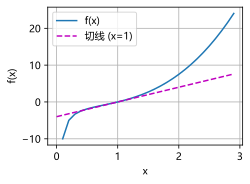

In [15]:
x = np.arange(0, 3, 0.1)
plot(x, [x ** 3 - 1 / x, 4 * x - 4], 'x', 'f(x)', legend=['f(x)', '切线 (x=1)'])

2. 求函数$f(\mathbf{x})=3x_{1}^{2}+5e^{x_{2}}$的梯度。

$$\nabla f(\mathbf{x})=\left(6x_1,5e^{x_2}\right)$$

3. 函数$f(\mathbf{x})=\|\mathbf{x}\|_2$的梯度是什么？

$$f(\mathbf{x}) = \sqrt{x_1^2 + x_2^2 + \cdots + x_n^2}$$
令$u = x_1^2 + x_2^2 + \cdots + x_n^2$，$f(u)=u^{1/2}$，
$$\frac{\partial f}{\partial x_i} = \frac{\partial f}{\partial u}\frac{\partial u}{\partial x_i} = \frac{1}{2}u^{-1/2}\frac{\partial u}{\partial x_i}$$
$$\frac{\partial u}{\partial x_i} = \frac{\partial}{\partial x_i} \left(x_1^2 + x_2^2 + \cdots + x_n^2 \right) = 2x_i$$
$$\frac{\partial f}{\partial x_i} = \frac{x_i}{\sqrt{u}} = \frac{x_i}{\sqrt{x_1^2 + x_2^2 + \cdots + x_n^2}}$$
$$\nabla f(\mathbf{x}) = \frac{\mathbf{x}}{\|\mathbf{x}\|}，其中\mathbf{x} \neq \mathbf{0}$$

4. 尝试写出函数$u=f(x,y,z)$，其中$x=x(a,b)$，$y=y(a,b)$，$z=z(a,b)$的链式法则。

$$\frac{\partial u}{\partial a} = \frac{\partial f}{\partial x} \frac{\partial x}{\partial a} + \frac{\partial f}{\partial y} \frac{\partial y}{\partial a} + \frac{\partial f}{\partial z} \frac{\partial z}{\partial a}$$
$$\frac{\partial u}{\partial b} = \frac{\partial f}{\partial x} \frac{\partial x}{\partial b} + \frac{\partial f}{\partial y} \frac{\partial y}{\partial b} + \frac{\partial f}{\partial z} \frac{\partial z}{\partial b}$$